In [1]:
from pathlib import Path
from shutil import rmtree
from json import dumps
from typing import Literal
from pickle import Pickler
from gzip import open as gz_open

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.compose import make_column_transformer, make_column_selector


RANDOM_STATE = 12345

# Data

In [2]:
def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    if which == "full":
        experiment["transformers"] = make_column_transformer(
            ("passthrough", number_selector),
            ("passthrough", bool_selector),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            remainder="drop",
            verbose_feature_names_out=False,
        )
    else:
        experiment["transformers"] = make_column_transformer(
            ("passthrough", number_selector),
            ("passthrough", bool_selector),
            remainder="drop",
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"decision_tree_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="all", overwrite=True)

X_train, y_train = experiment["train"]
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Experiment

## Training pipe

In [4]:
model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformers"]),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [5]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    # `min_samples_leaf` : offer a bit more of regularization for the training
    "model__min_samples_leaf": [3, 5, 7],
    # `max_depth`      : is too restrictive a measure of complexity
    # `max_leaf_nodes` : represents the level of partitioning of the training data
    # `max_leaf_nodes` : too many partitions can mean overfitting
    "model__max_leaf_nodes": [800, 1600, 3200, None],
}

In [6]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
    return_train_score=True,
)

grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 24 candidates, totalling 96 fits
[CV 2/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.729, test=0.680) total time=  18.7s
[CV 4/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.714, test=0.674) total time=  18.6s
[CV 3/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.723, test=0.679) total time=  19.5s
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3;, score=(train=0.722, test=0.675) total time=  19.7s
[CV 2/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5;, score=(train=0.723, test=0.676) total time=  16.0s
[CV 4/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5;, score=(train=0.712, test=0.671) total time=  15.7s
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=

## Cross-validation results

In [7]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_leaf_nodes,param_model__min_samples_leaf,params,split0_test_score,split1_test_score,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
21,9.507408,0.051244,0.293075,0.056136,entropy,None,3,"{'model__criterion': 'entropy', 'model__max_le...",0.731824,0.736867,...,0.731206,0.735130,0.003858,1,0.846411,0.846761,0.850568,0.847895,0.847909,0.001630
9,14.627796,0.682272,0.301063,0.038008,gini,None,3,"{'model__criterion': 'gini', 'model__max_leaf_...",0.728280,0.728589,...,0.732597,0.730878,0.002499,2,0.846280,0.841902,0.847260,0.845643,0.845271,0.002029
22,9.465897,0.787485,0.241672,0.012097,entropy,None,5,"{'model__criterion': 'entropy', 'model__max_le...",0.710648,0.722967,...,0.714482,0.718397,0.006054,3,0.801272,0.799576,0.809892,0.803963,0.803676,0.003915
10,14.207874,0.250896,0.264163,0.042242,gini,None,5,"{'model__criterion': 'gini', 'model__max_leaf_...",0.711038,0.705455,...,0.708511,0.710074,0.003604,4,0.799960,0.797223,0.802592,0.802251,0.800506,0.002149
6,18.051923,0.451394,0.269354,0.016179,gini,3200,3,"{'model__criterion': 'gini', 'model__max_leaf_...",0.702803,0.705815,...,0.711732,0.707129,0.003268,5,0.796198,0.793354,0.795547,0.797067,0.795542,0.001373
18,9.907941,0.100016,0.287689,0.042934,entropy,3200,3,"{'model__criterion': 'entropy', 'model__max_le...",0.695924,0.706215,...,0.696274,0.701551,0.005482,6,0.782380,0.788886,0.792816,0.786871,0.787738,0.003760
23,9.032410,0.093279,0.272811,0.039302,entropy,None,7,"{'model__criterion': 'entropy', 'model__max_le...",0.689944,0.705513,...,0.698917,0.700963,0.007396,7,0.768684,0.768515,0.779185,0.771482,0.771966,0.004331
7,16.587146,0.277365,0.294414,0.044424,gini,3200,5,"{'model__criterion': 'gini', 'model__max_leaf_...",0.698191,0.692501,...,0.699150,0.697774,0.003240,8,0.777945,0.775362,0.780324,0.780836,0.778617,0.002173
19,9.184761,0.175846,0.277225,0.018992,entropy,3200,5,"{'model__criterion': 'entropy', 'model__max_le...",0.693524,0.703124,...,0.690694,0.697376,0.005373,9,0.772016,0.769073,0.779032,0.771480,0.772900,0.003710
20,9.922036,0.198118,0.254005,0.028664,entropy,3200,7,"{'model__criterion': 'entropy', 'model__max_le...",0.684882,0.699612,...,0.689441,0.693587,0.006631,10,0.758153,0.757334,0.770616,0.761980,0.762021,0.005263


## Feature importance

In [8]:
feature_names = trained_pipe["transformer"].get_feature_names_out()

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_pipe["model"].feature_importances_,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

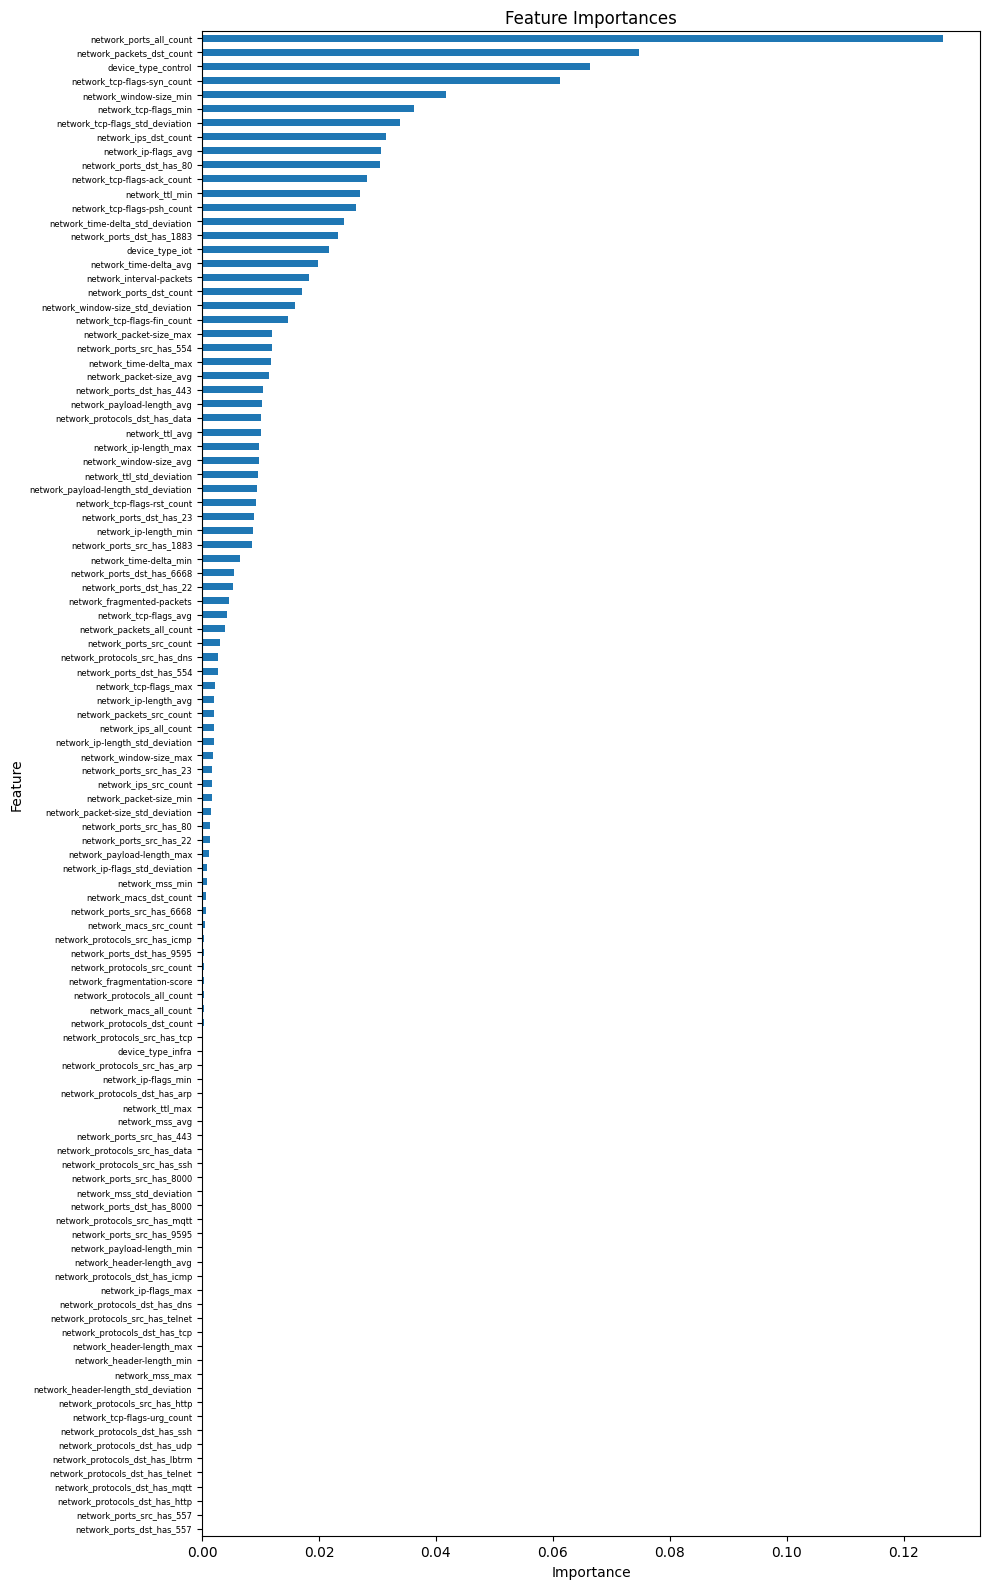

In [9]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [10]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [12]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [13]:
trained_tree = trained_model.tree_

model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "tree_structure": {
        "n_nodes": int(trained_tree.node_count),
        "n_leafs": int(trained_tree.n_leaves),
        "max_depth": int(trained_tree.max_depth),
    }
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__criterion": "entropy",
    "model__max_leaf_nodes": null,
    "model__min_samples_leaf": 3
  },
  "all_parameters": {
    "ccp_alpha": 0.0,
    "class_weight": "balanced",
    "criterion": "entropy",
    "max_depth": null,
    "max_features": null,
    "max_leaf_nodes": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 3,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "random_state": 12345,
    "splitter": "best"
  },
  "tree_structure": {
    "n_nodes": 18645,
    "n_leafs": 9323,
    "max_depth": 47
  }
}
